In [52]:
# LOAD DATA
import pandas as pd
import numpy as np
import openpyxl

cargo_freqawal = pd.read_excel(
    "/content/cargo_imputed.xlsx",
    engine="openpyxl", sheet_name ="cargo_frequency"
)

In [53]:
cargo_freqawal.isna().sum()

,0
cargo_value,0
weight,0
route_risk,0
distance,0
transit_duration,0
pilot_experience,0
vessel_age,0
solar_radiation,0
debris_density,0
exposure,0


In [54]:
cargo_freqawal

,cargo_value,weight,route_risk,distance,transit_duration,pilot_experience,vessel_age,solar_radiation,debris_density,exposure,cargo_type_clean,container_type_clean,claim_count_same
0,11070000.0,135000.0,4,25.037326,6.619,18.017,19.380,0.288,0.127,0.340,lithium,QuantumCrate Module,0
1,8320000.0,160000.0,5,33.690000,20.794,12.828,6.305,0.255,0.296,0.148,cobalt,DockArc Freight Case,3
2,12300000.0,150000.0,1,10.930000,6.445,6.039,31.811,0.076,0.252,0.289,lithium,QuantumCrate Module,0
3,500000.0,50000.0,4,13.490000,9.583,17.533,9.695,0.150,0.350,0.813,supplies,DockArc Freight Case,0
4,2550000.0,30000.0,3,1.580000,1.000,17.157,19.357,0.149,0.000,0.959,rare earths,DeepSpace Haulbox,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
124977,1750000.0,250000.0,2,1.580000,1.000,15.323,19.682,0.226,0.209,0.337,titanium,LongHaul Vault Canister,0
124978,2550000.0,30000.0,3,25.770000,15.370,17.426,33.249,0.234,0.153,0.748,rare earths,DockArc Freight Case,0
124979,8610000.0,105000.0,3,25.670000,11.497,12.446,19.711,0.152,0.213,0.530,lithium,DockArc Freight Case,0
124980,610200000.0,4500.0,2,40.370000,36.080,7.297,33.932,0.295,0.267,0.430,gold,LongHaul Vault Canister,0


## SIGNIFIKANSI

In [55]:
# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Stats & GLM
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
import xgboost as xgb

import time

In [56]:
print("\n🗂️  STEP 4: Mendefinisikan kolom...")

RESPONSE = 'claim_count_same'

NUMERIC_COLS = [
    'cargo_value', 'weight', 'distance', 'transit_duration',
    'pilot_experience', 'vessel_age', 'solar_radiation', 'debris_density'
]
CATEGORICAL_COLS = ['cargo_type_clean', 'route_risk', 'container_type_clean']
ALL_PREDICTORS   = NUMERIC_COLS + CATEGORICAL_COLS

print(f"  Numerik   : {NUMERIC_COLS}")
print(f"  Kategorik : {CATEGORICAL_COLS}")
print(f"  Response  : {RESPONSE}")
print("✅ STEP 4 selesai!")


🗂️  STEP 4: Mendefinisikan kolom...
  Numerik   : ['cargo_value', 'weight', 'distance', 'transit_duration', 'pilot_experience', 'vessel_age', 'solar_radiation', 'debris_density']
  Kategorik : ['cargo_type_clean', 'route_risk', 'container_type_clean']
  Response  : claim_count_same
✅ STEP 4 selesai!


In [57]:
# ============================================================
# STEP 6: CEK OVERDISPERSION
# Poisson: mean == variance
# Jika variance >> mean → pakai Negative Binomial
# ============================================================
print("\n🔍 STEP 6: Cek Overdispersion pada Response...")

df_model = cargo_freqawal[ALL_PREDICTORS + [RESPONSE]].copy()


y_mean = df_model[RESPONSE].mean()
y_var  = df_model[RESPONSE].var()
disp_ratio = y_var / y_mean

print(f"  Mean response     : {y_mean:.4f}")
print(f"  Variance response : {y_var:.4f}")
print(f"  Dispersion ratio  : {disp_ratio:.4f}  (variance / mean)")

if disp_ratio > 1.5:
    print("  ⚠️  OVERDISPERSED! variance >> mean → Negative Binomial lebih cocok dari Poisson")
    OVERDISPERSED = True
elif disp_ratio < 0.8:
    print("  ⚠️  UNDERDISPERSED! variance < mean")
    OVERDISPERSED = False
else:
    print("  ✅ Tidak overdispersed — Poisson cocok")
    OVERDISPERSED = False

print("✅ STEP 6 selesai!")



🔍 STEP 6: Cek Overdispersion pada Response...
  Mean response     : 0.2445
  Variance response : 0.3492
  Dispersion ratio  : 1.4281  (variance / mean)
  ✅ Tidak overdispersed — Poisson cocok
✅ STEP 6 selesai!


In [58]:
# ============================================================
# STEP 7: IQR CAPPING + LOG TRANSFORM pada numerik
# ============================================================
print("\n✂️  STEP 7: IQR Capping + Log Transform...")

LOG_COLS = ['cargo_value', 'weight', 'distance', 'debris_density', 'solar_radiation']

# IQR Capping
for col in NUMERIC_COLS:
    Q1, Q3 = df_model[col].quantile(0.25), df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    df_model[col] = df_model[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# Log transform
for col in LOG_COLS:
    min_val = df_model[col].min()
    if min_val <= 0:
        df_model[col] = df_model[col] - min_val + 1e-6
    df_model[col] = np.log1p(df_model[col])

print(f"  Capping & log transform selesai pada: {LOG_COLS}")
print("✅ STEP 7 selesai!")



✂️  STEP 7: IQR Capping + Log Transform...
  Capping & log transform selesai pada: ['cargo_value', 'weight', 'distance', 'debris_density', 'solar_radiation']
✅ STEP 7 selesai!


In [59]:
# ============================================================
# STEP 8: ENCODING & SCALING
# Dua versi:
#   A. df_glm  → untuk GLM statsmodels (pakai formula, kategorik sbg string)
#   B. df_ml   → untuk RF & XGBoost (label encoded + scaled)
# ============================================================
print("\n🔡 STEP 8: Encoding & Scaling...")

# ── Versi A: GLM (kategorik tetap string, statsmodels handle otomatis) ──
df_glm = df_model.copy()
# Pastikan kategorik sebagai 'category' dtype
for col in CATEGORICAL_COLS:
    df_glm[col] = df_glm[col].astype('category')

# ── Versi B: ML (label encode + standard scale numerik) ──
df_ml   = df_model.copy()
le_dict = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le

scaler = StandardScaler()
df_ml[NUMERIC_COLS] = scaler.fit_transform(df_ml[NUMERIC_COLS])

print(f"  df_glm shape : {df_glm.shape}  (untuk GLM)")
print(f"  df_ml shape  : {df_ml.shape}   (untuk RF & XGBoost)")
print("✅ STEP 8 selesai!")



🔡 STEP 8: Encoding & Scaling...
  df_glm shape : (124982, 12)  (untuk GLM)
  df_ml shape  : (124982, 12)   (untuk RF & XGBoost)
✅ STEP 8 selesai!


In [60]:
# ============================================================
# STEP 9: TRAIN-TEST SPLIT
# ============================================================
print("\n✂️  STEP 9: Train-Test Split (80/20)...")

# GLM split
X_glm = df_glm[ALL_PREDICTORS]
y_glm = df_glm[RESPONSE]
X_glm_train, X_glm_test, y_glm_train, y_glm_test = train_test_split(
    X_glm, y_glm, test_size=0.2, random_state=42
)
df_glm_train = pd.concat([X_glm_train, y_glm_train], axis=1)
df_glm_test  = pd.concat([X_glm_test,  y_glm_test],  axis=1)

# ML split
X_ml = df_ml[ALL_PREDICTORS].values
y_ml = df_ml[RESPONSE].values
X_train, X_test, y_train, y_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42
)

print(f"  Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print("✅ STEP 9 selesai!")


✂️  STEP 9: Train-Test Split (80/20)...
  Train: 99,985 | Test: 24,997
✅ STEP 9 selesai!


In [61]:
# ============================================================
# HELPER: Fungsi Evaluasi Regresi
# ============================================================
def eval_regression(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Mean Absolute Percentage Error
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return {"model": model_name, "RMSE": round(rmse,4),
            "MAE": round(mae,4), "R2": round(r2,4), "MAPE(%)": round(mape,2)}



#model

In [62]:
# ============================================================
# STEP 10: MODEL 1 — GLM POISSON
# ============================================================
print("\n" + "="*60)
print("🔵 STEP 10: GLM POISSON")
print("="*60)

# Build formula
num_terms = " + ".join(NUMERIC_COLS)
cat_terms = " + ".join([f"C({c})" for c in CATEGORICAL_COLS])
formula_poisson = f"{RESPONSE} ~ {num_terms} + {cat_terms}"
print(f"  Formula: {formula_poisson[:100]}...")

t0 = time.time()
glm_poisson = smf.glm(
    formula  = formula_poisson,
    data     = df_glm_train,
    family   = sm.families.Poisson()
).fit()
t1 = time.time()

print(glm_poisson.summary())

# Prediksi
y_pred_poisson_test = glm_poisson.predict(df_glm_test)
result_poisson = eval_regression(
    y_glm_test.values, y_pred_poisson_test.values, "GLM Poisson"
)
result_poisson['time_s'] = round(t1-t0, 2)
print(f"\n  ✅ Poisson — RMSE={result_poisson['RMSE']} | MAE={result_poisson['MAE']} | R²={result_poisson['R2']}")

# Koefisien & p-value Poisson
coef_poisson = pd.DataFrame({
    'variable'  : glm_poisson.params.index,
    'coef'      : glm_poisson.params.values,
    'std_err'   : glm_poisson.bse.values,
    'z_value'   : glm_poisson.tvalues.values,
    'p_value'   : glm_poisson.pvalues.values,
    'IRR'       : np.exp(glm_poisson.params.values),   # Incidence Rate Ratio
}).sort_values('p_value')
coef_poisson['significant'] = coef_poisson['p_value'] < 0.05
print("\n  Top 15 variabel signifikan (Poisson):")
print(coef_poisson[coef_poisson['variable'] != 'Intercept'].head(15).to_string(index=False))



🔵 STEP 10: GLM POISSON
  Formula: claim_count_same ~ cargo_value + weight + distance + transit_duration + pilot_experience + vessel_ag...
                 Generalized Linear Model Regression Results                  
Dep. Variable:       claim_count_same   No. Observations:                99985
Model:                            GLM   Df Residuals:                    99962
Model Family:                 Poisson   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -63795.
Date:                Mon, 09 Mar 2026   Deviance:                       87786.
Time:                        13:20:30   Pearson chi2:                 1.43e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.001642
Covariance Type:            nonrobust                                         
                                                         coef    std er

In [63]:
# ============================================================
# STEP 11: MODEL 2 — GLM NEGATIVE BINOMIAL
# (lebih robust jika overdispersed)
# ============================================================
print("\n" + "="*60)
print("🟤 STEP 11: GLM NEGATIVE BINOMIAL")
print("="*60)

t0 = time.time()
glm_nb = smf.glm(
    formula  = formula_poisson,   # formula sama
    data     = df_glm_train,
    family   = sm.families.NegativeBinomial()
).fit()
t1 = time.time()

print(glm_nb.summary())

y_pred_nb_test = glm_nb.predict(df_glm_test)
result_nb = eval_regression(
    y_glm_test.values, y_pred_nb_test.values, "GLM NegBin"
)
result_nb['time_s'] = round(t1-t0, 2)
print(f"\n  ✅ NegBin — RMSE={result_nb['RMSE']} | MAE={result_nb['MAE']} | R²={result_nb['R2']}")

coef_nb = pd.DataFrame({
    'variable'  : glm_nb.params.index,
    'coef'      : glm_nb.params.values,
    'std_err'   : glm_nb.bse.values,
    'z_value'   : glm_nb.tvalues.values,
    'p_value'   : glm_nb.pvalues.values,
    'IRR'       : np.exp(glm_nb.params.values),
}).sort_values('p_value')
coef_nb['significant'] = coef_nb['p_value'] < 0.05
print("\n  Top 15 variabel signifikan (NegBin):")
print(coef_nb[coef_nb['variable'] != 'Intercept'].head(15).to_string(index=False))



🟤 STEP 11: GLM NEGATIVE BINOMIAL
                 Generalized Linear Model Regression Results                  
Dep. Variable:       claim_count_same   No. Observations:                99985
Model:                            GLM   Df Residuals:                    99962
Model Family:        NegativeBinomial   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -61520.
Date:                Mon, 09 Mar 2026   Deviance:                       66722.
Time:                        13:20:32   Pearson chi2:                 1.15e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.001334
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

In [64]:
# ============================================================
# STEP 12: MODEL 3 — RANDOM FOREST
# ============================================================
print("\n" + "="*60)
print("🟢 STEP 12: RANDOM FOREST")
print("="*60)

# Subsample untuk efisiensi training RF (50rb cukup representatif)
SUBSAMPLE_RF = 50_000
np.random.seed(42)
sub_idx = np.random.choice(len(X_train), min(SUBSAMPLE_RF, len(X_train)), replace=False)
X_train_rf = X_train[sub_idx]
y_train_rf = y_train[sub_idx]

print(f"  Training RF pada {len(X_train_rf):,} data (subsample)...")
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_rf, y_train_rf)
t1 = time.time()

y_pred_rf = rf.predict(X_test)
result_rf  = eval_regression(y_test, y_pred_rf, "Random Forest")
result_rf['time_s'] = round(t1-t0, 2)
print(f"  ✅ RF — RMSE={result_rf['RMSE']} | MAE={result_rf['MAE']} | R²={result_rf['R2']}")

# Feature Importance RF
fi_rf = pd.DataFrame({
    'variable'  : ALL_PREDICTORS,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)
fi_rf['rank']           = fi_rf.index + 1
fi_rf['importance_pct'] = (fi_rf['importance'] / fi_rf['importance'].sum() * 100).round(2)
fi_rf['cumulative_pct'] = fi_rf['importance_pct'].cumsum().round(2)

print("\n  Feature Importance Random Forest:")
print(fi_rf.to_string(index=False))




🟢 STEP 12: RANDOM FOREST
  Training RF pada 50,000 data (subsample)...
  ✅ RF — RMSE=0.5943 | MAE=0.4018 | R²=-0.0

  Feature Importance Random Forest:
            variable  importance  rank  importance_pct  cumulative_pct
    pilot_experience    0.150316     1           15.03           15.03
          vessel_age    0.132254     2           13.23           28.26
      debris_density    0.126446     3           12.64           40.90
     solar_radiation    0.122472     4           12.25           53.15
    transit_duration    0.122363     5           12.24           65.39
            distance    0.122251     6           12.23           77.62
              weight    0.065821     7            6.58           84.20
         cargo_value    0.063978     8            6.40           90.60
container_type_clean    0.034487     9            3.45           94.05
          route_risk    0.034301    10            3.43           97.48
    cargo_type_clean    0.025312    11            2.53          10

In [65]:
# ============================================================
# STEP 13: MODEL 4 — XGBOOST
# ============================================================
print("\n" + "="*60)
print("🟡 STEP 13: XGBOOST")
print("="*60)

# XGBoost pakai objective count:poisson untuk count data
print("  Training XGBoost (objective=count:poisson)...")
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    objective       = 'count:poisson',   # khusus count data
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 10,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    n_jobs          = -1,
    random_state    = 42,
    verbosity       = 0
)
xgb_model.fit(
    X_train, y_train,
    eval_set        = [(X_test, y_test)],
    verbose         = False
)
t1 = time.time()

y_pred_xgb = xgb_model.predict(X_test)
result_xgb  = eval_regression(y_test, y_pred_xgb, "XGBoost")
result_xgb['time_s'] = round(t1-t0, 2)
print(f"  ✅ XGBoost — RMSE={result_xgb['RMSE']} | MAE={result_xgb['MAE']} | R²={result_xgb['R2']}")

# Feature Importance XGBoost (3 jenis)
fi_xgb_weight = xgb_model.get_booster().get_score(importance_type='weight')
fi_xgb_gain   = xgb_model.get_booster().get_score(importance_type='gain')
fi_xgb_cover  = xgb_model.get_booster().get_score(importance_type='cover')

# Map f0, f1, ... ke nama kolom asli
feature_names = ALL_PREDICTORS
feat_map = {f'f{i}': name for i, name in enumerate(feature_names)}

fi_xgb = pd.DataFrame({
    'variable': feature_names,
    'weight'  : [fi_xgb_weight.get(f'f{i}', 0) for i in range(len(feature_names))],
    'gain'    : [fi_xgb_gain.get(f'f{i}', 0)   for i in range(len(feature_names))],
    'cover'   : [fi_xgb_cover.get(f'f{i}', 0)  for i in range(len(feature_names))],
})
fi_xgb['gain_pct'] = (fi_xgb['gain'] / fi_xgb['gain'].sum() * 100).round(2)
fi_xgb = fi_xgb.sort_values('gain', ascending=False).reset_index(drop=True)
fi_xgb['rank'] = fi_xgb.index + 1

print("\n  Feature Importance XGBoost (sorted by gain):")
print(fi_xgb.to_string(index=False))



🟡 STEP 13: XGBOOST
  Training XGBoost (objective=count:poisson)...
  ✅ XGBoost — RMSE=0.5941 | MAE=0.3994 | R²=0.0009

  Feature Importance XGBoost (sorted by gain):
            variable  weight     gain       cover  gain_pct  rank
          route_risk   455.0 4.090052 9859.310547     10.10     1
    transit_duration  1636.0 3.818652 3853.734131      9.43     2
            distance  1792.0 3.800027 4451.106445      9.38     3
      debris_density  2093.0 3.746878 4740.493652      9.25     4
          vessel_age  2106.0 3.725410 4069.555664      9.20     5
     solar_radiation  2124.0 3.717845 4633.026855      9.18     6
    pilot_experience  2108.0 3.697047 5623.084473      9.13     7
              weight  1012.0 3.639648 3728.407227      8.98     8
         cargo_value  1000.0 3.505016 4222.559082      8.65     9
    cargo_type_clean   374.0 3.455260 4676.196289      8.53    10
container_type_clean   528.0 3.312759 3841.898438      8.18    11


In [66]:
# ============================================================
# STEP 14: EVALUASI METRIK — PERBANDINGAN SEMUA MODEL
# ============================================================
print("\n" + "="*60)
print("📊 STEP 14: EVALUASI METRIK PERBANDINGAN")
print("="*60)

# Gabung semua hasil
results = pd.DataFrame([result_poisson, result_nb, result_rf, result_xgb])

print("\n📋 Tabel Evaluasi:")
print(results[['model','RMSE','MAE','R2','MAPE(%)','time_s']].to_string(index=False))

# Composite Score
def normalize_minmax(series, higher_is_better=True):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5]*len(series), index=series.index)
    norm = (series - mn) / (mx - mn)
    return norm if higher_is_better else (1 - norm)

results['norm_rmse'] = normalize_minmax(results['RMSE'], higher_is_better=False)
results['norm_mae']  = normalize_minmax(results['MAE'],  higher_is_better=False)
results['norm_r2']   = normalize_minmax(results['R2'],   higher_is_better=True)

# Bobot: RMSE 40%, R² 40%, MAE 20%
results['composite_score'] = (
    0.40 * results['norm_rmse'] +
    0.40 * results['norm_r2']  +
    0.20 * results['norm_mae']
)

print("\n📊 Composite Score (RMSE=40%, R²=40%, MAE=20%):")
print(results[['model','RMSE','MAE','R2','composite_score','time_s']].to_string(index=False))

best_model_name = results.loc[results['composite_score'].idxmax(), 'model']
print(f"\n🏆 MODEL TERBAIK: {best_model_name}")

# Catatan overdispersion
if OVERDISPERSED:
    print(f"\n⚠️  Data overdispersed (ratio={disp_ratio:.2f}) → GLM Negative Binomial")
    print("    lebih valid secara statistik dibanding Poisson,")
    print("    meski tree-based bisa punya RMSE lebih baik.")



📊 STEP 14: EVALUASI METRIK PERBANDINGAN

📋 Tabel Evaluasi:
        model   RMSE    MAE      R2  MAPE(%)  time_s
  GLM Poisson 0.5938 0.4001  0.0016    78.88    1.72
   GLM NegBin 0.5938 0.4002  0.0016    78.88    1.76
Random Forest 0.5943 0.4018 -0.0000    78.75   18.09
      XGBoost 0.5941 0.3994  0.0009    78.85    6.07

📊 Composite Score (RMSE=40%, R²=40%, MAE=20%):
        model   RMSE    MAE      R2  composite_score  time_s
  GLM Poisson 0.5938 0.4001  0.0016         0.941667    1.72
   GLM NegBin 0.5938 0.4002  0.0016         0.933333    1.76
Random Forest 0.5943 0.4018 -0.0000         0.000000   18.09
      XGBoost 0.5941 0.3994  0.0009         0.585000    6.07

🏆 MODEL TERBAIK: GLM Poisson


In [67]:
# ============================================================
# STEP 15: RINGKASAN VARIABEL PALING BERPENGARUH
# ============================================================
print("\n" + "="*60)
print("🎯 STEP 15: RINGKASAN VARIABEL PALING BERPENGARUH")
print("="*60)

# Ambil top variabel tiap model (exclude intercept & dummy kategorik)
def clean_glm_varname(name):
    """Ekstrak nama variabel asli dari nama term GLM."""
    if name == 'Intercept': return None
    if name.startswith('C(') and '[' in name:
        base = name.split('(')[1].split(')')[0]
        return base
    return name

# Top GLM Poisson
top_poisson = (coef_poisson[coef_poisson['variable'] != 'Intercept']
               .assign(var_clean=lambda x: x['variable'].apply(clean_glm_varname))
               .dropna(subset=['var_clean'])
               .groupby('var_clean')
               .apply(lambda g: g.loc[g['p_value'].idxmin()])
               .sort_values('p_value')
               .head(8)[['var_clean','coef','IRR','p_value','significant']])

# Top GLM NegBin
top_nb = (coef_nb[coef_nb['variable'] != 'Intercept']
          .assign(var_clean=lambda x: x['variable'].apply(clean_glm_varname))
          .dropna(subset=['var_clean'])
          .groupby('var_clean')
          .apply(lambda g: g.loc[g['p_value'].idxmin()])
          .sort_values('p_value')
          .head(8)[['var_clean','coef','IRR','p_value','significant']])

# Top RF
top_rf = fi_rf.head(8)[['variable','importance_pct','cumulative_pct']]

# Top XGBoost
top_xgb = fi_xgb.head(8)[['variable','gain_pct']]

print("\n🔵 Top 8 — GLM Poisson (sorted by p-value):")
print(top_poisson.to_string())

print("\n🟤 Top 8 — GLM Negative Binomial (sorted by p-value):")
print(top_nb.to_string())

print("\n🟢 Top 8 — Random Forest (sorted by importance):")
print(top_rf.to_string(index=False))

print("\n🟡 Top 8 — XGBoost (sorted by gain):")
print(top_xgb.to_string(index=False))

# ── Konsensus: variabel yang muncul konsisten di semua model ──
print("\n" + "-"*50)
print("🏆 KONSENSUS — Variabel paling konsisten berpengaruh:")
sets = [
    set(top_poisson['var_clean'].tolist()),
    set(top_nb['var_clean'].tolist()),
    set(top_rf['variable'].tolist()),
    set(top_xgb['variable'].tolist()),
]
consensus_all  = sets[0] & sets[1] & sets[2] & sets[3]
consensus_3    = set()
for i in range(4):
    for j in range(i+1, 4):
        for k in range(j+1, 4):
            consensus_3 |= sets[i] & sets[j] & sets[k]
consensus_3 -= consensus_all

print(f"  Muncul di SEMUA 4 model : {sorted(consensus_all) if consensus_all else '(tidak ada)'}")
print(f"  Muncul di 3 dari 4 model: {sorted(consensus_3)  if consensus_3  else '(tidak ada)'}")



🎯 STEP 15: RINGKASAN VARIABEL PALING BERPENGARUH

🔵 Top 8 — GLM Poisson (sorted by p-value):
                                 var_clean      coef       IRR       p_value  significant
var_clean                                                                                
route_risk                      route_risk  0.196776  1.217472  1.947195e-13         True
pilot_experience          pilot_experience -0.006294  0.993726  1.120737e-06         True
cargo_value                    cargo_value -0.061776  0.940093  3.358278e-03         True
debris_density              debris_density  0.209289  1.232801  8.962004e-03         True
container_type_clean  container_type_clean  0.050524  1.051822  1.188200e-02         True
cargo_type_clean          cargo_type_clean -0.103283  0.901872  2.312343e-02         True
solar_radiation            solar_radiation  0.153089  1.165429  5.593174e-02        False
vessel_age                      vessel_age -0.000904  0.999096  1.710055e-01        False

🟤 Top

In [68]:
top_poisson

,var_clean,coef,IRR,p_value,significant
var_clean,,,,,
route_risk,route_risk,0.196776,1.217472,1.947195e-13,True
pilot_experience,pilot_experience,-0.006294,0.993726,1.120737e-06,True
cargo_value,cargo_value,-0.061776,0.940093,3.358278e-03,True
debris_density,debris_density,0.209289,1.232801,8.962004e-03,True
container_type_clean,container_type_clean,0.050524,1.051822,1.188200e-02,True
cargo_type_clean,cargo_type_clean,-0.103283,0.901872,2.312343e-02,True
solar_radiation,solar_radiation,0.153089,1.165429,5.593174e-02,False
vessel_age,vessel_age,-0.000904,0.999096,1.710055e-01,False



🎨 STEP 16: Visualisasi...
  ✅ Plot disimpan: 'variable_importance_analysis.png'


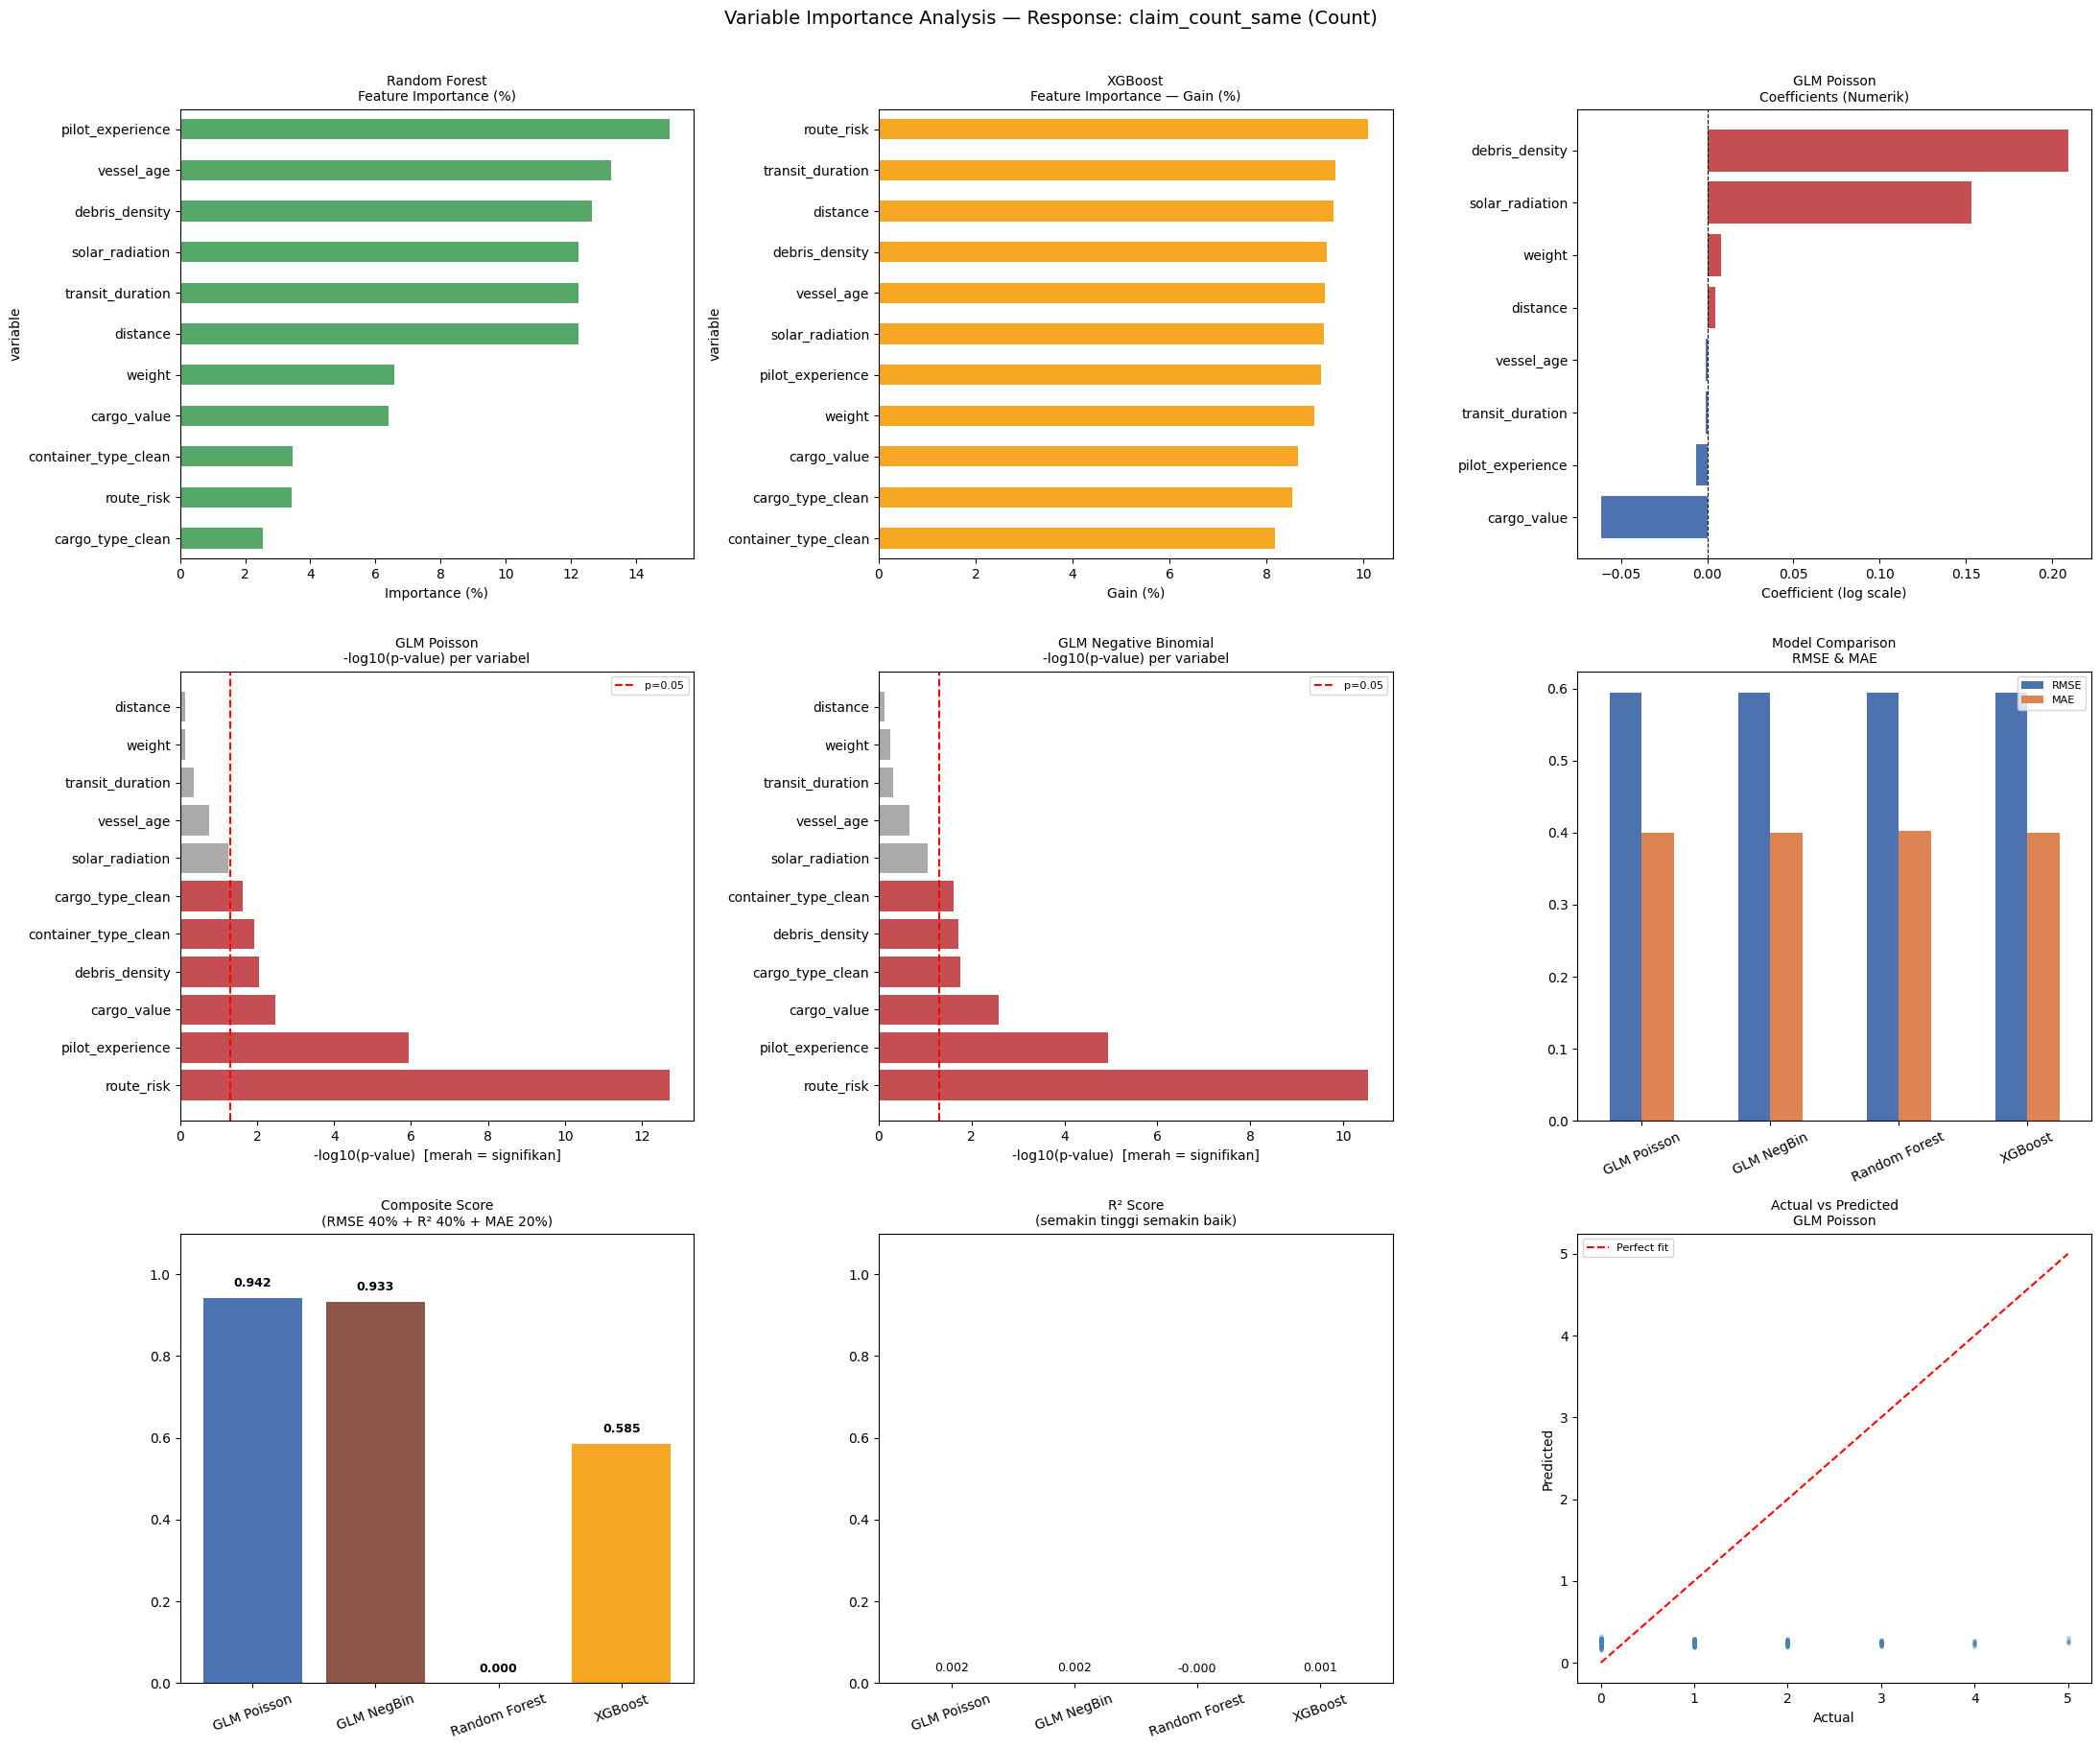

In [69]:
# ============================================================
# STEP 16: VISUALISASI
# ============================================================
print("\n🎨 STEP 16: Visualisasi...")

fig = plt.figure(figsize=(22, 18))
fig.suptitle(f"Variable Importance Analysis — Response: {RESPONSE} (Count)",
             fontsize=14, y=1.01)

# ── Row 1: Feature Importance RF & XGBoost ──
ax1 = fig.add_subplot(3, 3, 1)
fi_rf_plot = fi_rf.set_index('variable')['importance_pct'].sort_values()
fi_rf_plot.plot(kind='barh', ax=ax1, color='#55A868')
ax1.set_title('Random Forest\nFeature Importance (%)', fontsize=10)
ax1.set_xlabel('Importance (%)')

ax2 = fig.add_subplot(3, 3, 2)
fi_xgb_plot = fi_xgb.set_index('variable')['gain_pct'].sort_values()
fi_xgb_plot.plot(kind='barh', ax=ax2, color='#F5A623')
ax2.set_title('XGBoost\nFeature Importance — Gain (%)', fontsize=10)
ax2.set_xlabel('Gain (%)')

# ── GLM Coef Plot (Poisson) — hanya main terms, exclude dummy ──
ax3 = fig.add_subplot(3, 3, 3)
coef_main = (coef_poisson[
    (~coef_poisson['variable'].str.startswith('C(')) &
    (coef_poisson['variable'] != 'Intercept')
].sort_values('coef'))
colors_coef = ['#C44E52' if v > 0 else '#4C72B0' for v in coef_main['coef']]
ax3.barh(coef_main['variable'], coef_main['coef'], color=colors_coef)
ax3.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax3.set_title('GLM Poisson\nCoefficients (Numerik)', fontsize=10)
ax3.set_xlabel('Coefficient (log scale)')

# ── Row 2: P-value plot GLM ──
ax4 = fig.add_subplot(3, 3, 4)
pval_plot = (coef_poisson[coef_poisson['variable'] != 'Intercept']
             .assign(var_clean=lambda x: x['variable'].apply(clean_glm_varname))
             .dropna()
             .groupby('var_clean')['p_value'].min()
             .sort_values())
bar_colors = ['#C44E52' if p < 0.05 else '#AAAAAA' for p in pval_plot.values]
ax4.barh(pval_plot.index, -np.log10(pval_plot.values + 1e-300), color=bar_colors)
ax4.axvline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
ax4.set_title('GLM Poisson\n-log10(p-value) per variabel', fontsize=10)
ax4.set_xlabel('-log10(p-value)  [merah = signifikan]')
ax4.legend(fontsize=8)

ax5 = fig.add_subplot(3, 3, 5)
pval_nb = (coef_nb[coef_nb['variable'] != 'Intercept']
           .assign(var_clean=lambda x: x['variable'].apply(clean_glm_varname))
           .dropna()
           .groupby('var_clean')['p_value'].min()
           .sort_values())
bar_colors_nb = ['#C44E52' if p < 0.05 else '#AAAAAA' for p in pval_nb.values]
ax5.barh(pval_nb.index, -np.log10(pval_nb.values + 1e-300), color=bar_colors_nb)
ax5.axvline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
ax5.set_title('GLM Negative Binomial\n-log10(p-value) per variabel', fontsize=10)
ax5.set_xlabel('-log10(p-value)  [merah = signifikan]')
ax5.legend(fontsize=8)

# ── Row 2 col 3: Model comparison ──
ax6 = fig.add_subplot(3, 3, 6)
metric_compare = results[['model','RMSE','MAE','R2']].set_index('model')
metric_compare[['RMSE','MAE']].plot(kind='bar', ax=ax6, color=['#4C72B0','#DD8452'])
ax6.set_title('Model Comparison\nRMSE & MAE', fontsize=10)
ax6.set_xlabel('')
ax6.tick_params(axis='x', rotation=25)
ax6.legend(fontsize=8)

# ── Row 3: Composite score + R² + Actual vs Predicted ──
ax7 = fig.add_subplot(3, 3, 7)
bars = ax7.bar(results['model'], results['composite_score'],
               color=['#4C72B0','#8C564B','#55A868','#F5A623'])
ax7.set_title('Composite Score\n(RMSE 40% + R² 40% + MAE 20%)', fontsize=10)
ax7.set_ylim(0, 1.1)
for bar, val in zip(bars, results['composite_score']):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax7.tick_params(axis='x', rotation=20)

ax8 = fig.add_subplot(3, 3, 8)
ax8.bar(results['model'], results['R2'],
        color=['#4C72B0','#8C564B','#55A868','#F5A623'])
ax8.set_title('R² Score\n(semakin tinggi semakin baik)', fontsize=10)
ax8.set_ylim(0, 1.1)
for bar, val in zip(bars, results['R2']):
    ax8.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax8.tick_params(axis='x', rotation=20)

# Actual vs Predicted — best model
ax9 = fig.add_subplot(3, 3, 9)
pred_map = {
    'GLM Poisson'   : y_pred_poisson_test.values,
    'GLM NegBin'    : y_pred_nb_test.values,
    'Random Forest' : y_pred_rf,
    'XGBoost'       : y_pred_xgb,
}
y_true_plot = y_test if best_model_name in ['Random Forest','XGBoost'] else y_glm_test.values
y_pred_plot = pred_map[best_model_name]
sample_plot = np.random.choice(len(y_true_plot), min(3000, len(y_true_plot)), replace=False)
ax9.scatter(y_true_plot[sample_plot], y_pred_plot[sample_plot],
            alpha=0.3, s=5, color='steelblue')
mn_val = min(y_true_plot.min(), y_pred_plot.min())
mx_val = max(y_true_plot.max(), y_pred_plot.max())
ax9.plot([mn_val, mx_val], [mn_val, mx_val], 'r--', lw=1.5, label='Perfect fit')
ax9.set_title(f'Actual vs Predicted\n{best_model_name}', fontsize=10)
ax9.set_xlabel('Actual'); ax9.set_ylabel('Predicted')
ax9.legend(fontsize=8)

plt.tight_layout()
plt.savefig('variable_importance_analysis.png', dpi=150, bbox_inches='tight')
print("  ✅ Plot disimpan: 'variable_importance_analysis.png'")
plt.show()


📊 FEATURE IMPORTANCE: VARIABEL SIGNIFIKAN (p < 0.05)
                                         variable      coef      IRR      p_value
                                   debris_density  0.209289 1.232801 8.962004e-03
                               C(route_risk)[T.5]  0.208279 1.231557 1.065872e-11
                               C(route_risk)[T.4]  0.196776 1.217472 1.947195e-13
                               C(route_risk)[T.3]  0.133153 1.142425 5.245876e-08
                               C(route_risk)[T.2]  0.110214 1.116517 2.772269e-05
                  C(cargo_type_clean)[T.supplies] -0.114368 0.891930 2.924648e-02
                  C(cargo_type_clean)[T.titanium] -0.103283 0.901872 2.312343e-02
                                      cargo_value -0.061776 0.940093 3.358278e-03
C(container_type_clean)[T.HardSeal Transit Crate]  0.050524 1.051822 1.188200e-02
   C(container_type_clean)[T.QuantumCrate Module]  0.040198 1.041017 4.633197e-02
                                 pilot_exper

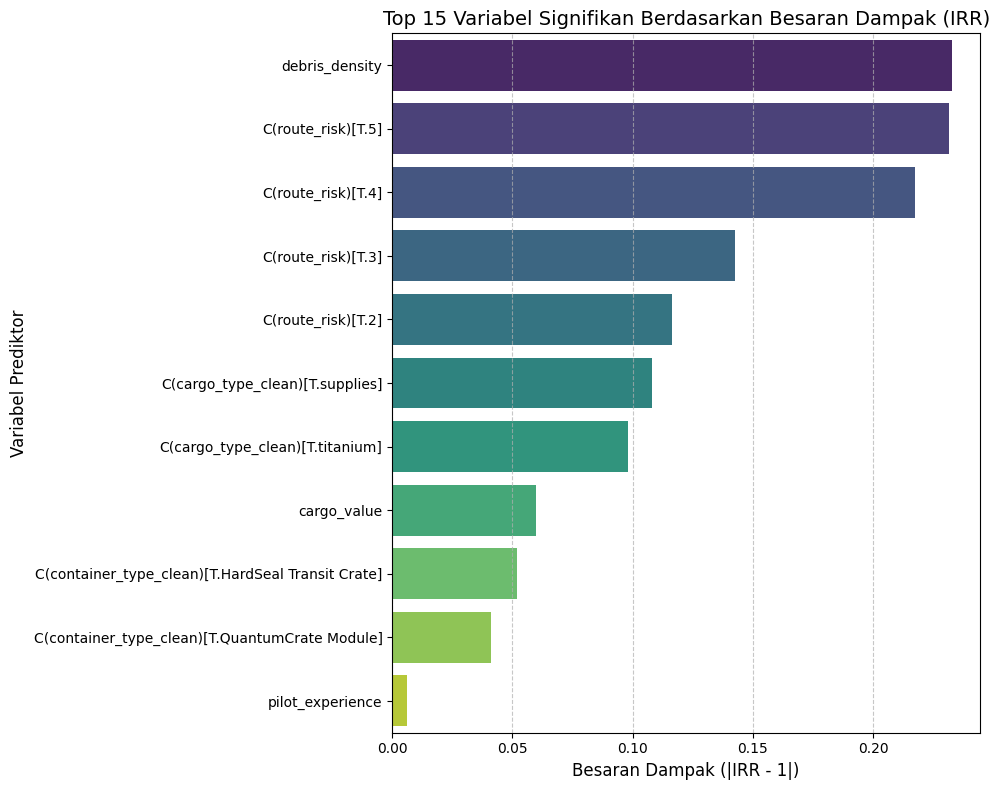

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter hanya variabel yang signifikan (p-value < 0.05)
# Kita keluarkan 'Intercept' agar tidak mengganggu skala visualisasi
df_significant = coef_poisson[
    (coef_poisson['variable'] != 'Intercept') &
    (coef_poisson['significant'] == True)
].copy()

# 2. Hitung 'Impact Score' (Seberapa jauh IRR menjauh dari angka 1)
# IRR > 1 berarti menaikkan klaim, IRR < 1 berarti menurunkan klaim
df_significant['impact_magnitude'] = (df_significant['IRR'] - 1).abs()
df_significant = df_significant.sort_values('impact_magnitude', ascending=False)

print("\n" + "="*60)
print("📊 FEATURE IMPORTANCE: VARIABEL SIGNIFIKAN (p < 0.05)")
print("="*60)
print(df_significant[['variable', 'coef', 'IRR', 'p_value']].head(15).to_string(index=False))

# 3. Visualisasi Top 15 Variabel Paling Berpengaruh
plt.figure(figsize=(10, 8))
sns.barplot(
    x='impact_magnitude',
    y='variable',
    data=df_significant.head(15),
    palette='viridis'
)

plt.title('Top 15 Variabel Signifikan Berdasarkan Besaran Dampak (IRR)', fontsize=14)
plt.xlabel('Besaran Dampak (|IRR - 1|)', fontsize=12)
plt.ylabel('Variabel Prediktor', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# BINING

In [71]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, export_text

# ============================================================
# KONFIGURASI DINAMIS
# ============================================================
RESPONSE = 'claim_count_same'  # ← Nama target/response variabel

# Tentukan variabel numerik yang akan di-binning
NUMERIC_BIN_COLS = ['pilot_experience', 'cargo_value', 'debris_density']

# Tentukan jumlah KELOMPOK (bins) spesifik per variabel
N_GROUPS_MAP = {
    'pilot_experience': 2,
    'cargo_value': 2,
    'debris_density': 3
}

MIN_LEAF = 20000  # Minimal observasi per bin (untuk stabilitas statistik)

# ============================================================
# STEP 1: BINNING NUMERIK — IMPURITY-BASED (CART)
# ============================================================
print("=" * 60)
print("🌳 STEP 1: OPTIMAL BINNING — NUMERIK (CART)")
print("=" * 60)

num_bin_results = {}

for col in NUMERIC_BIN_COLS:
    current_n_groups = N_GROUPS_MAP.get(col, 3) # Default ke 3 jika tidak ada di map

    print(f"\n{'─'*60}")
    print(f" 📐 Variabel: {col} | Target Bins: {current_n_groups}")
    print(f"{'─'*60}")

    # 1. Ambil data (X) dan Target (y)
    X_col  = cargo_freqawal[[col]].values
    y_resp = cargo_freqawal[RESPONSE].values

    # 2. Fit Decision Tree Regressor (CART)
    tree = DecisionTreeRegressor(
        max_leaf_nodes   = current_n_groups,
        min_samples_leaf = MIN_LEAF,
        random_state     = 42
    )
    tree.fit(X_col, y_resp)

    # 3. Ambil Cut Points (Thresholds)
    thresholds = sorted(set(t for t in tree.tree_.threshold if t != -2.0))

    print(f"  Struktur Decision Tree:")
    print(export_text(tree, feature_names=[col]))
    print(f"  Cut points : {[round(t, 4) for t in thresholds]}")

    # 4. Fungsi Labeling & Ordinal Otomatis (Handle N-Bins)
    def get_bin_info(v, cuts):
        if not cuts:
            return "All", 0

        # Cari posisi v di dalam list cuts
        idx = np.searchsorted(cuts, v)

        # Buat Label
        if idx == 0:
            label = f"Group 1 (≤{cuts[0]:,.4f})"
        elif idx == len(cuts):
            label = f"Group {idx+1} (>{cuts[-1]:,.4f})"
        else:
            label = f"Group {idx+1} ({cuts[idx-1]:,.4f}–{cuts[idx]:,.4f}]"

        return label, idx

    # Terapkan Labeling
    temp_apply = cargo_freqawal[col].apply(lambda x: get_bin_info(x, thresholds))
    cargo_freqawal[f'{col}_bin_label']   = temp_apply.apply(lambda x: x[0])
    cargo_freqawal[f'{col}_bin_ordinal'] = temp_apply.apply(lambda x: x[1])

    # 5. Hitung Statistik per Bin
    stats = (
        cargo_freqawal
        .groupby([f'{col}_bin_ordinal', f'{col}_bin_label'])
        .agg(
            n           = (RESPONSE, 'count'),
            mean_resp   = (RESPONSE, 'mean'),
            mean_var    = (col,      'mean'),
            min_var     = (col,      'min'),
            max_var     = (col,      'max'),
        )
        .reset_index()
        .sort_values(f'{col}_bin_ordinal')
    )

    stats['pct'] = (stats['n'] / len(cargo_freqawal) * 100).round(2)
    # WOE sederhana (log of bin mean vs global mean)
    global_mean = cargo_freqawal[RESPONSE].mean()
    stats['woe'] = np.log(stats['mean_resp'] / global_mean)

    print(f"\n  Statistik per bin [{col}]:")
    print(stats[[f'{col}_bin_ordinal', f'{col}_bin_label',
                  'n', 'pct', 'mean_var', 'mean_resp', 'woe'
                  ]].round(4).to_string(index=False))

    # 6. Cek Monotonisitas
    means = stats['mean_resp'].values
    if len(means) > 1:
        if all(means[i] <= means[i+1] for i in range(len(means)-1)):
            mono = "✅ Monoton naik"
        elif all(means[i] >= means[i+1] for i in range(len(means)-1)):
            mono = "✅ Monoton turun"
        else:
            mono = "⚠️ Tidak monoton"
    else:
        mono = "— (1 bin)"
    print(f"  Tren: {mono}")

    num_bin_results[col] = {'cuts': thresholds, 'stats': stats}

print("\n" + "="*60)
print("✅ SEMUA PROSES BINNING SELESAI")
print("="*60)

🌳 STEP 1: OPTIMAL BINNING — NUMERIK (CART)

────────────────────────────────────────────────────────────
 📐 Variabel: pilot_experience | Target Bins: 2
────────────────────────────────────────────────────────────
  Struktur Decision Tree:
|--- pilot_experience <= 17.12
|   |--- value: [0.25]
|--- pilot_experience >  17.12
|   |--- value: [0.23]

  Cut points : [np.float64(17.1225)]

  Statistik per bin [pilot_experience]:
 pilot_experience_bin_ordinal pilot_experience_bin_label     n   pct  mean_var  mean_resp     woe
                            0         Group 1 (≤17.1225) 83088 66.48   12.2719     0.2506  0.0245
                            1         Group 2 (>17.1225) 41894 33.52   20.4223     0.2325 -0.0505
  Tren: ✅ Monoton turun

────────────────────────────────────────────────────────────
 📐 Variabel: cargo_value | Target Bins: 2
────────────────────────────────────────────────────────────
  Struktur Decision Tree:
|--- cargo_value <= 1487500.00
|   |--- value: [0.25]
|--- cargo_

In [72]:
# ============================================================
# STEP 2: BINNING KATEGORIK — LOW vs HIGH ONLY
# ============================================================
print("\n" + "=" * 60)
print("🏷️  STEP 2: BINNING KATEGORIK — LOW vs HIGH (MEAN RESPONSE)")
print("=" * 60)


CATEGORICAL_BIN_COLS = ["route_risk", "container_type_clean"]
cat_bin_results = {}
N_GROUPS_CAT = 2  # Kita paksa jadi 2 kelompok saja

for col in CATEGORICAL_BIN_COLS:
    print(f"\n{'─'*50}")
    print(f"  📂 Variabel: {col}")
    print(f"{'─'*50}")

    # 1. Hitung mean response per kategori dan urutkan
    mean_by_cat = (
        cargo_freqawal.groupby(col)[RESPONSE]
        .mean()
        .sort_values()
        .reset_index()
        .rename(columns={RESPONSE: 'mean_resp'})
    )

    # 2. Bagi menjadi 2 kelompok (Low/High) menggunakan pd.qcut
    # Jika kategori sedikit, kita gunakan ranking untuk memastikan pembagian rata
    mean_by_cat['group_ordinal'] = pd.qcut(
        mean_by_cat['mean_resp'].rank(method='first'), # Gunakan rank agar pembagian stabil
        q      = N_GROUPS_CAT,
        labels = False
    ).astype(int)

    # 3. Labeling (0 = Low, 1 = High)
    label_map_grp = {0: 'Low', 1: 'High'}
    mean_by_cat['group_label'] = mean_by_cat['group_ordinal'].map(label_map_grp)

    print(f"  Mapping kategori → group:")
    print(mean_by_cat[[col, 'mean_resp', 'group_ordinal', 'group_label']].to_string(index=False))

    # 4. Map ke dataframe utama
    map_ordinal = dict(zip(mean_by_cat[col], mean_by_cat['group_ordinal']))
    map_label   = dict(zip(mean_by_cat[col], mean_by_cat['group_label']))

    cargo_freqawal[f'{col}_bin_ordinal'] = cargo_freqawal[col].map(map_ordinal)
    cargo_freqawal[f'{col}_bin_label']   = cargo_freqawal[col].map(map_label)

    # 5. Statistik per bin
    stats_cat = (
        cargo_freqawal
        .groupby([f'{col}_bin_ordinal', f'{col}_bin_label'])
        .agg(
            n         = (RESPONSE, 'count'),
            mean_resp = (RESPONSE, 'mean'),
            std_resp  = (RESPONSE, 'std'),
        )
        .reset_index()
        .sort_values(f'{col}_bin_ordinal')
    )
    stats_cat['pct'] = (stats_cat['n'] / len(cargo_freqawal) * 100).round(2)

    # WOE calculation
    global_mean = cargo_freqawal[RESPONSE].mean()
    stats_cat['woe'] = np.log(stats_cat['mean_resp'] / global_mean)

    # Info kategori dalam group
    for grp_ord in sorted(mean_by_cat['group_ordinal'].unique()):
        cats_in_grp = mean_by_cat.loc[mean_by_cat['group_ordinal'] == grp_ord, col].tolist()
        print(f"    Group {grp_ord} [{label_map_grp[grp_ord]}]: {cats_in_grp}")

    print(f"\n  Statistik per bin [{col}]:")
    print(stats_cat[[f'{col}_bin_ordinal', f'{col}_bin_label',
                      'n', 'pct', 'mean_resp', 'woe'
                      ]].round(4).to_string(index=False))

    cat_bin_results[col] = {
        'mapping' : mean_by_cat,
        'stats'   : stats_cat,
    }


🏷️  STEP 2: BINNING KATEGORIK — LOW vs HIGH (MEAN RESPONSE)

──────────────────────────────────────────────────
  📂 Variabel: route_risk
──────────────────────────────────────────────────
  Mapping kategori → group:
 route_risk  mean_resp  group_ordinal group_label
          1   0.209027              0         Low
          2   0.232710              0         Low
          3   0.244695              0         Low
          4   0.261477              1        High
          5   0.270314              1        High
    Group 0 [Low]: [1, 2, 3]
    Group 1 [High]: [4, 5]

  Statistik per bin [route_risk]:
 route_risk_bin_ordinal route_risk_bin_label     n   pct  mean_resp     woe
                      0                  Low 88021 70.43     0.2362 -0.0348
                      1                 High 36961 29.57     0.2644  0.0782

──────────────────────────────────────────────────
  📂 Variabel: container_type_clean
──────────────────────────────────────────────────
  Mapping kategori → group

In [73]:
# ============================================================
# STEP 3: WEIGHT BINNING (CUTOFF 72500)
# ============================================================
# Asumsi kolom weight bernama 'weight' atau ganti sesuai kolommu
WEIGHT_COL = 'weight'
CUTOFF_WEIGHT = np.float64(72500.0)

def bin_weight(w):
    return 'Low_Weight' if w <= CUTOFF_WEIGHT else 'High_Weight'

cargo_freqawal[f'{WEIGHT_COL}_bin_label'] = cargo_freqawal[WEIGHT_COL].apply(bin_weight)

# ============================================================
# STEP 3: MEMBUAT KOMBINASI KELOMPOK (SEGMENTATION KEY)
# ============================================================

bin_cols = [
    'pilot_experience_bin_label',
    'cargo_value_bin_label',
    'debris_density_bin_label',
    'route_risk_bin_label',
    'container_type_clean_bin_label',
    'weight_bin_label'
]

# buat key kombinasi
cargo_freqawal['segment_key'] = cargo_freqawal[bin_cols].astype(str).agg('|'.join, axis=1)

# ============================================================
#ubah kombinasi jdi nomor kelompok

segment_map = (
    cargo_freqawal[['segment_key'] + bin_cols]
    .drop_duplicates()
    .reset_index(drop=True)
)

segment_map['group_number'] = segment_map.index + 1


cargo_freqawal = cargo_freqawal.merge(
    segment_map[['segment_key','group_number']],
    on='segment_key',
    how='left'
)

In [74]:
cols_drop = [c for c in cargo_freqawal.columns if '_bin_' in c] + ['segment_key']

final_data = cargo_freqawal.drop(columns=cols_drop)

In [75]:
final_data.to_excel(
    "data_dengan_kelompok.xlsx",
    index=False
)

In [76]:
mapping_kelompok = segment_map.drop(columns=['segment_key'])

mapping_kelompok.to_excel(
    "mapping_kelompok.xlsx",
    index=False
)

In [77]:
# LOAD DATA
import pandas as pd
import numpy as np
import openpyxl

cargo_sev = pd.read_excel(
    "/content/cargo_imputed.xlsx",
    engine="openpyxl", sheet_name ="cargo_severity"
)

In [78]:
for col, info in num_bin_results.items():

    cuts = info['cuts']

    def get_bin_info(v, cuts):
        if not cuts:
            return "All", 0

        idx = np.searchsorted(cuts, v)

        if idx == 0:
            label = f"Group 1 (≤{cuts[0]:,.4f})"
        elif idx == len(cuts):
            label = f"Group {idx+1} (>{cuts[-1]:,.4f})"
        else:
            label = f"Group {idx+1} ({cuts[idx-1]:,.4f}–{cuts[idx]:,.4f}]"

        return label, idx

    temp_apply = cargo_sev[col].apply(lambda x: get_bin_info(x, cuts))

    cargo_sev[f'{col}_bin_label']   = temp_apply.apply(lambda x: x[0])
    cargo_sev[f'{col}_bin_ordinal'] = temp_apply.apply(lambda x: x[1])

In [79]:
for col, info in cat_bin_results.items():

    mapping = info['mapping']

    map_ordinal = dict(zip(mapping[col], mapping['group_ordinal']))
    map_label   = dict(zip(mapping[col], mapping['group_label']))

    cargo_sev[f'{col}_bin_ordinal'] = cargo_sev[col].map(map_ordinal)
    cargo_sev[f'{col}_bin_label']   = cargo_sev[col].map(map_label)

In [80]:
WEIGHT_COL = 'weight'
CUTOFF_WEIGHT = np.float64(72500.0)

def bin_weight(w):
    return 'Low_Weight' if w <= CUTOFF_WEIGHT else 'High_Weight'

cargo_sev[f'{WEIGHT_COL}_bin_label'] = cargo_sev[WEIGHT_COL].apply(bin_weight)

In [81]:
bin_cols = [
    'pilot_experience_bin_label',
    'cargo_value_bin_label',
    'debris_density_bin_label',
    'route_risk_bin_label',
    'container_type_clean_bin_label',
    'weight_bin_label'
]

cargo_sev['segment_key'] = cargo_sev[bin_cols].astype(str).agg('|'.join, axis=1)

In [82]:
cargo_sev = cargo_sev.merge(
    segment_map[['segment_key','group_number']],
    on='segment_key',
    how='left'
)

In [83]:
cols_drop = [c for c in cargo_sev.columns if '_bin_' in c] + ['segment_key']

cargo_sev_final = cargo_sev.drop(columns=cols_drop)

In [84]:
cargo_sev_final.to_excel(
    "cargo_sev_dengan_kelompok.xlsx",
    index=False
)